# Chesapeake Bay Nutrient Loads — Quick Look Demo

A first-look exploration of the [`OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads`](https://huggingface.co/datasets/BAIGroup/OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads) dataset: 14,200 monthly nutrient observations from 121 USGS gauges across the Chesapeake watershed (2014–2021), with quantile-binned class labels for total nitrogen (TN), total phosphorus (TP), and sediment loading.

## What You'll Learn

- How to pull the dataset directly from Hugging Face with `datasets.load_dataset`
- The schema and the *physical-unit thresholds* that anchor the 0–3 quantile classes
- Which stations dominate watershed loading, and where they sit geographically
- How loading varies seasonally at a high-burden station (with spring-runoff context)
- How TN loading compares across sub-basins

## Why

For Civil & Environmental Engineering practitioners new to this dataset, the orientation question is: *which stations matter, and what does a "high" load class mean in absolute terms?* This demo answers both — fast — before committing to the longer reproduction, training, or analysis notebooks.

## Requirements

- Python 3.11
- `pandas`, `matplotlib`, `datasets`, `numpy` (see `requirements.txt`)
- ~1 minute runtime on a laptop, no GPU required

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

# --- Constants reused throughout the notebook ---
LOAD_METRICS = ['tn_load', 'tp_load', 'sediment_load']
LOAD_LABELS = {
    'tn_load':       'Total nitrogen',
    'tp_load':       'Total phosphorus',
    'sediment_load': 'Sediment',
}
LOAD_UNITS = 'kg/month'
LOAD_CLASS_COLS = ['tn_load_class', 'tp_load_class', 'sediment_load_class']

CLASS_LABELS = {0: 'Q1 (low)', 1: 'Q2', 2: 'Q3', 3: 'Q4 (high)'}
METRIC_COLORS = ['#1976d2', '#43a047', '#c0392b']

## 1. Load the dataset

Pull straight from the Hugging Face Hub. First call downloads (~few MB); later calls hit the local cache.

In [2]:
ds = load_dataset("BAIGroup/OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads")
df = ds["train"].to_pandas()
print(f"Rows: {len(df):,}  |  Stations: {df['STAID'].nunique()}  |  Years: {df['Year'].min()}-{df['Year'].max()}")
df.head()

Rows: 14,166  |  Stations: 121  |  Years: 2014-2023


,STAID,Year,Month,sediment_load,tn_load,tp_load,sediment_load_class,tn_load_class,tp_load_class,sediment_load_flow_norm,tn_load_flow_norm,tp_load_flow_norm,station_name,latitude,longitude,huc,state_code,subbasin,task_id
0,01486000,2014,1,668.0,88.1,4.06,0.0,0,0.0,True,True,True,"MANOKIN BRANCH NEAR PRINCESS ANNE, MD",38.213889,-75.671389,2080110,24,patuxent_choptank,ac29abf9-3e8e-5e98-b071-c49e36c94fc6
1,01486000,2014,2,1360.0,117.0,6.52,0.0,0,0.0,True,True,True,"MANOKIN BRANCH NEAR PRINCESS ANNE, MD",38.213889,-75.671389,2080110,24,patuxent_choptank,ac29abf9-3e8e-5e98-b071-c49e36c94fc6
2,01486000,2014,3,1780.0,109.0,7.15,0.0,0,0.0,True,True,True,"MANOKIN BRANCH NEAR PRINCESS ANNE, MD",38.213889,-75.671389,2080110,24,patuxent_choptank,ac29abf9-3e8e-5e98-b071-c49e36c94fc6
3,01486000,2014,4,876.0,62.9,4.15,0.0,0,0.0,True,True,True,"MANOKIN BRANCH NEAR PRINCESS ANNE, MD",38.213889,-75.671389,2080110,24,patuxent_choptank,ac29abf9-3e8e-5e98-b071-c49e36c94fc6
4,01486000,2014,5,1980.0,64.3,6.43,0.0,0,0.0,True,True,True,"MANOKIN BRANCH NEAR PRINCESS ANNE, MD",38.213889,-75.671389,2080110,24,patuxent_choptank,ac29abf9-3e8e-5e98-b071-c49e36c94fc6


## 2. What the class labels actually mean

The integer labels (`*_class`, 0–3) are quantile bins of the underlying load values. Reporting the *thresholds in physical units* makes the classes interpretable for engineering decisions (e.g., "a station consistently in Q4 is delivering > X kg/month of TN").

In [3]:
rows = []
for metric in LOAD_METRICS:
    qs = df[metric].quantile([0.25, 0.5, 0.75]).values
    rng = (df[metric].min(), df[metric].max())
    rows.append({
        'metric':      LOAD_LABELS[metric],
        'units':       LOAD_UNITS,
        'min':         f"{rng[0]:,.1f}",
        'Q1 ceiling':  f"{qs[0]:,.1f}",
        'Q2 ceiling':  f"{qs[1]:,.1f}",
        'Q3 ceiling':  f"{qs[2]:,.1f}",
        'max':         f"{rng[1]:,.1f}",
    })
pd.DataFrame(rows).set_index('metric')

,units,min,Q1 ceiling,Q2 ceiling,Q3 ceiling,max
metric,,,,,,
Total nitrogen,kg/month,6.3,497.2,"2,010.0","7,020.0","650,000.0"
Total phosphorus,kg/month,0.4,45.3,148.0,597.8,"41,000.0"
Sediment,kg/month,192.0,"21,425.0","94,550.0","380,000.0","40,400,000.0"


## 3. Where does the loading actually come from?

Watershed-scale management cares less about which station has the most records and more about which stations *deliver* the most load. Rank stations by mean monthly TN load to surface the highest-burden gauges.

In [4]:
station_summary = (
    df.groupby('STAID')
      .agg(
          station_name=('station_name', 'first'),
          subbasin=('subbasin', 'first'),
          mean_tn=('tn_load', 'mean'),
          mean_tp=('tp_load', 'mean'),
          mean_sed=('sediment_load', 'mean'),
          n_months=('tn_load', 'count'),
      )
      .sort_values('mean_tn', ascending=False)
)
print("Top 10 stations by mean monthly TN load:")
station_summary.head(10).round(0)

Top 10 stations by mean monthly TN load:


,station_name,subbasin,mean_tn,mean_tp,mean_sed,n_months
STAID,,,,,,
01578310,"SUSQUEHANNA RIVER AT CONOWINGO, MD",susquehanna,344167.0,17293.0,8958000.0,120
01576000,"Susquehanna River at Marietta, PA",susquehanna,285832.0,18943.0,16155214.0,117
01570500,"Susquehanna River at Harrisburg, PA",susquehanna,227325.0,14102.0,12825726.0,117
01554000,"Susquehanna River at Sunbury, PA",susquehanna,149363.0,11824.0,12841538.0,117
01646580,"POTOMAC RIVER AT CHAIN BRIDGE, AT WASHINGTON, DC",potomac,118352.0,9711.0,7461775.0,120
01540500,"Susquehanna River at Danville, PA",susquehanna,91569.0,9954.0,11327949.0,117
01536500,"Susquehanna River at Wilkes-Barre, PA",susquehanna,82995.0,10026.0,11538376.0,117
01531500,"Susquehanna River at Towanda, PA",susquehanna,60519.0,7060.0,8348034.0,117
01553500,"West Branch Susquehanna River at Lewisburg, PA",susquehanna,50354.0,2506.0,2593650.0,117


## 4. Map of stations colored by loading magnitude

A scatter of all 121 gauges colored by their mean TN load (log scale). Larger and warmer markers = higher delivered load. The hottest stations cluster geographically — useful context for prioritizing monitoring or modeling.

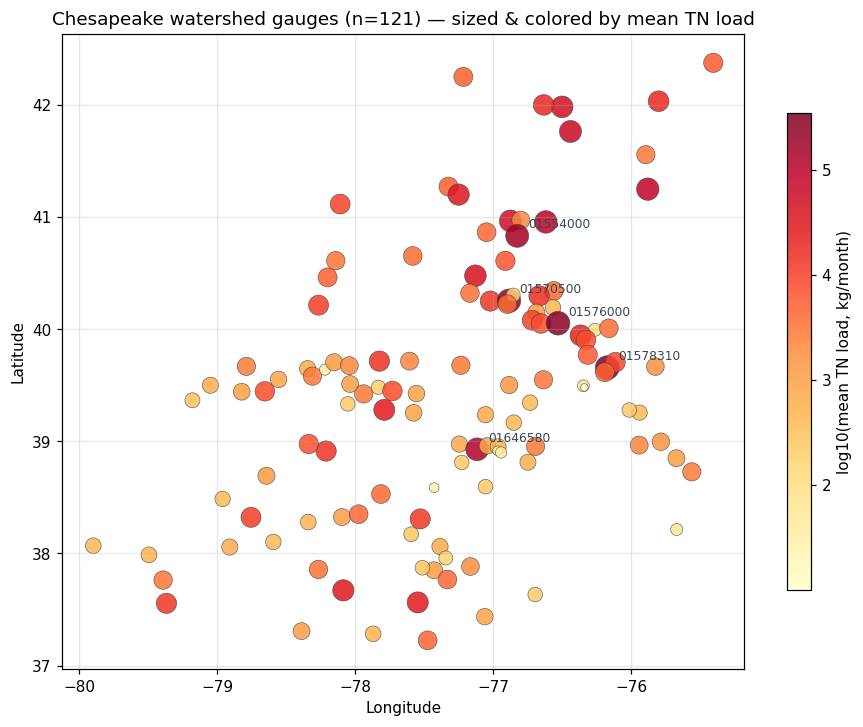

In [5]:
station_geo = (
    df.drop_duplicates('STAID')[['STAID', 'station_name', 'latitude', 'longitude', 'subbasin']]
      .merge(station_summary[['mean_tn', 'mean_tp', 'mean_sed']], on='STAID')
)

log_tn = np.log10(station_geo['mean_tn'].clip(lower=1))
sizes = 25 + (log_tn - log_tn.min()) / (log_tn.max() - log_tn.min() + 1e-9) * 220

fig, ax = plt.subplots(figsize=(10, 7.5))
sc = ax.scatter(
    station_geo['longitude'], station_geo['latitude'],
    c=log_tn, s=sizes, cmap='YlOrRd',
    edgecolor='#37474f', linewidth=0.4, alpha=0.85,
)
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label("log10(mean TN load, kg/month)")

# Label the top-5 highest-loading stations
top5 = station_geo.nlargest(5, 'mean_tn')
for _, r in top5.iterrows():
    ax.annotate(r['STAID'], (r['longitude'], r['latitude']),
                xytext=(7, 5), textcoords='offset points', fontsize=8, color='#37474f')

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Chesapeake watershed gauges (n={len(station_geo)}) — sized & colored by mean TN load")
ax.grid(alpha=0.3)
plt.show()

## 5. Seasonal loading at the highest-TN station

Pick the top-TN station and plot all three load series over time. Log scale handles the multi-order-of-magnitude range. Light blue bars mark the spring runoff window (Mar–May) — historically the peak loading season for the Bay.

Highest-TN-loading station: 01578310 - SUSQUEHANNA RIVER AT CONOWINGO, MD


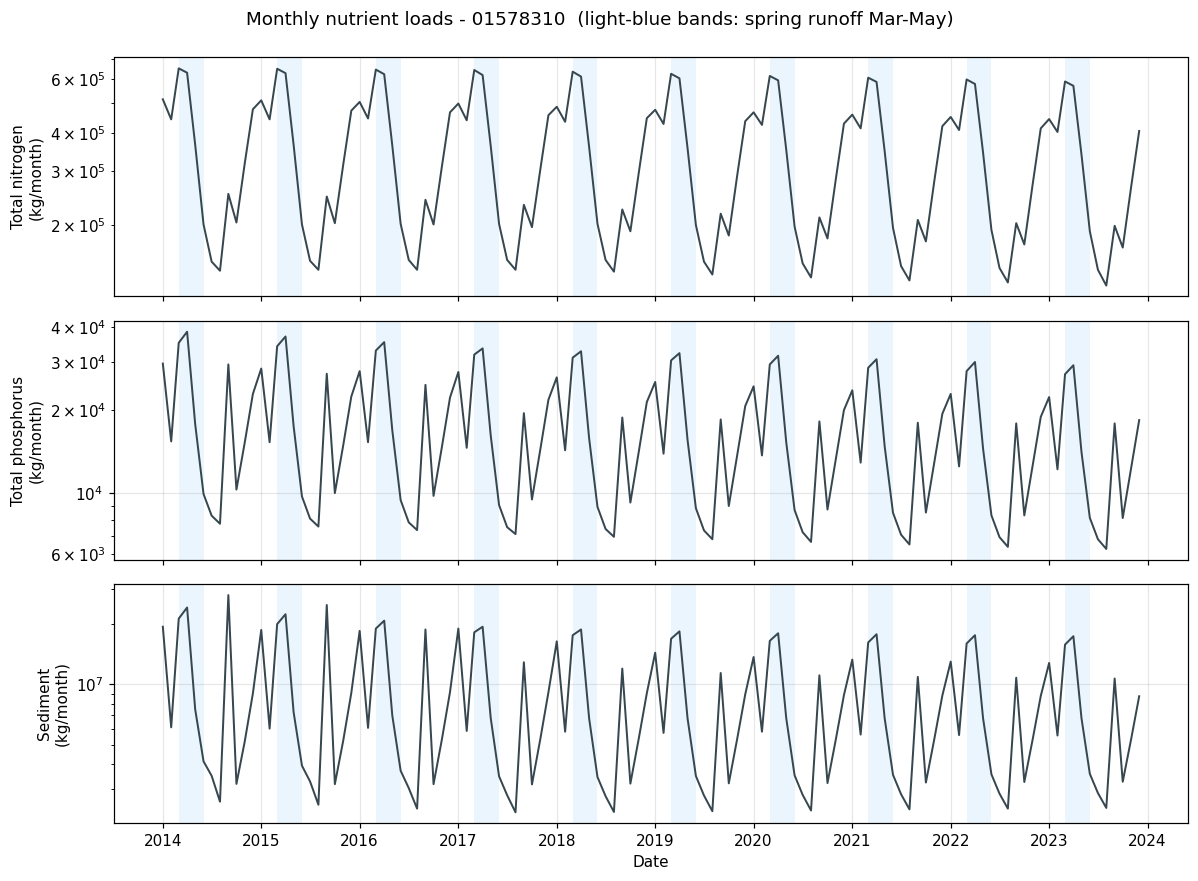

In [6]:
top_staid = station_summary.index[0]
top_name = station_summary.loc[top_staid, 'station_name']
print(f"Highest-TN-loading station: {top_staid} - {top_name}")

s = df[df['STAID'] == top_staid].copy()
s['date'] = pd.to_datetime({'year': s['Year'], 'month': s['Month'], 'day': 1})
s = s.sort_values('date')

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, metric in zip(axes, LOAD_METRICS):
    for yr in range(int(s['Year'].min()), int(s['Year'].max()) + 1):
        ax.axvspan(pd.Timestamp(yr, 3, 1), pd.Timestamp(yr, 6, 1),
                   color='#90caf9', alpha=0.18, lw=0)
    ax.plot(s['date'], s[metric], lw=1.3, color='#37474f')
    ax.set_yscale('log')
    ax.set_ylabel(f"{LOAD_LABELS[metric]}\n({LOAD_UNITS})")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Monthly nutrient loads - {top_staid}  (light-blue bands: spring runoff Mar-May)",
             y=0.995)
plt.tight_layout()
plt.show()

## 6. Quantile-bin class distribution

Sanity check: because the classes are quantile-derived across the full dataset, each metric's bins are uniform by construction. The interesting question — *does a station sit in the same quantile every month?* — is addressed in `04_analysis_results.ipynb`.

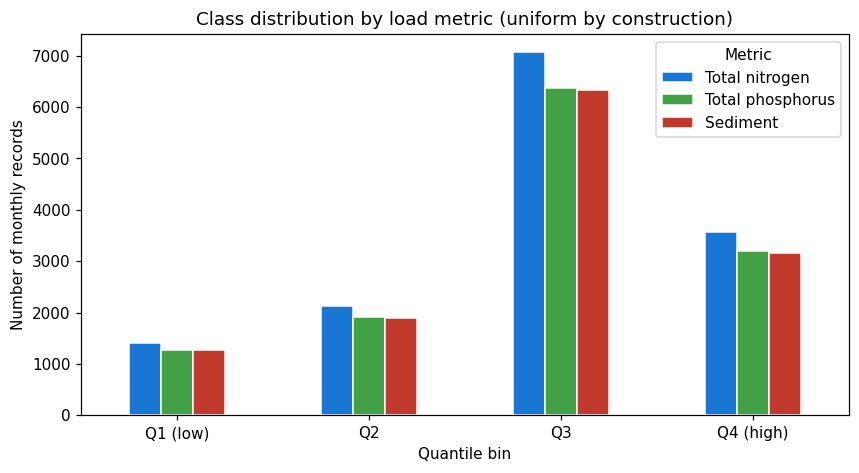

,Total nitrogen,Total phosphorus,Sediment
Q1 (low),1409,1277,1267
Q2,2118,1914,1897
Q3,7070,6380,6330
Q4 (high),3569,3191,3160


In [7]:
class_counts = pd.DataFrame({
    LOAD_LABELS[col.replace('_class', '')]: df[col].value_counts().sort_index()
    for col in LOAD_CLASS_COLS
})
class_counts.index = [CLASS_LABELS[i] for i in class_counts.index]

ax = class_counts.plot(kind='bar', figsize=(9, 4.5), edgecolor='white', color=METRIC_COLORS)
ax.set_xlabel("Quantile bin")
ax.set_ylabel("Number of monthly records")
ax.set_title("Class distribution by load metric (uniform by construction)")
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.show()
class_counts

## 7. Sub-basin comparison

Box-and-whisker of TN load by sub-basin highlights which parts of the watershed contribute disproportionately. Outlier dots above the whiskers are individual high-loading station-months.

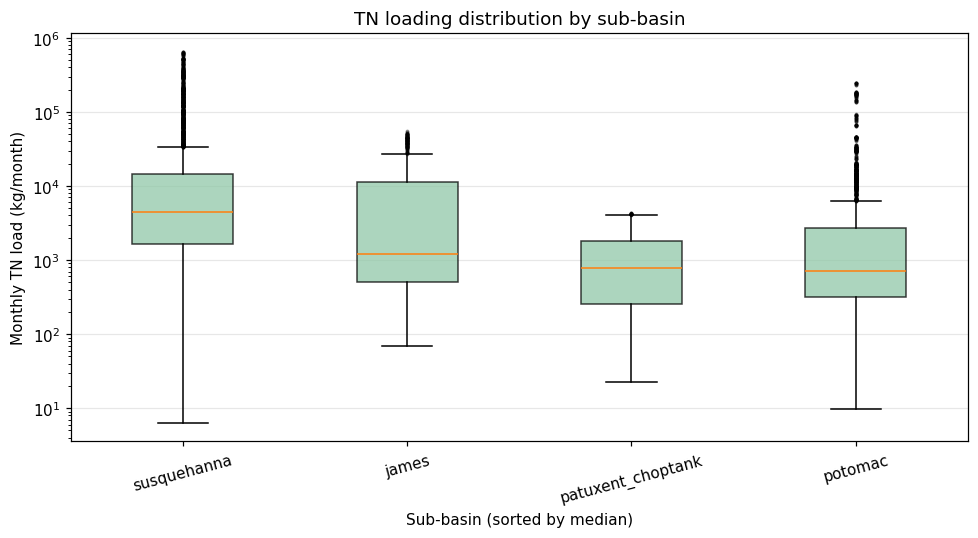

In [8]:
subbasin_order = (
    df.groupby('subbasin')['tn_load'].median().sort_values(ascending=False).index.tolist()
)
data = [df.loc[df['subbasin'] == sb, 'tn_load'].values for sb in subbasin_order]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data, tick_labels=subbasin_order, patch_artist=True, showfliers=True,
                flierprops=dict(marker='.', markersize=3, alpha=0.4))
for patch in bp['boxes']:
    patch.set_facecolor('#90c8a8')
    patch.set_alpha(0.75)
ax.set_yscale('log')
ax.set_ylabel("Monthly TN load (kg/month)")
ax.set_xlabel("Sub-basin (sorted by median)")
ax.set_title("TN loading distribution by sub-basin")
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## What you've seen, and what's next

**Takeaways from this 1-minute look:**

- The dataset cleanly resolves loading at 121 USGS gauges, with three nutrient/sediment metrics each on a 4-tier (Q1–Q4) class scale anchored to physical-unit thresholds.
- The top-10 highest-TN stations cluster in specific sub-basins — these are the watershed segments where management interventions (e.g., TMDL-driven reductions) would have the largest absolute impact.
- The classes are uniform across the dataset by construction; per-station class persistence (does a station sit in Q4 every month?) is the more actionable question, addressed in `04_analysis_results.ipynb`.
- Spring (Mar–May) loading dominates at the highest-burden station, consistent with snowmelt + spring-rain runoff signatures observed in the broader Chesapeake monitoring literature.

**Next notebooks in this repo:**

- **`02_data_prep_reproduce.ipynb`** — rebuild the dataset end-to-end from raw USGS NWIS pulls, including the quantile-bin construction.
- **`03_tutorial_embeddings_rf.ipynb`** — predict the 4-tier load classes from OlmoEarth satellite embeddings using a Random Forest, with confusion-matrix evaluation.
- **`04_analysis_results.ipynb`** — cross-station synthesis: per-station class persistence, sub-basin contribution rankings, and seasonal patterns.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*